<a href="https://colab.research.google.com/github/archangel2006/SatQuery/blob/main/SatQuery%20Final_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset1: BigEarthNet.txt textual annotations**
https://huggingface.co/datasets/BIFOLD-BigEarthNetv2-0/BigEarthNet.txt

## **Step 1 — Download only the 467 MB BigEarthNet.txt**

In [1]:
from huggingface_hub import hf_hub_download

path = hf_hub_download(
    repo_id="BIFOLD-BigEarthNetv2-0/BigEarthNet.txt",
    filename="BigEarthNet.txt.parquet",
    repo_type="dataset"
)

print(path)

BigEarthNet.txt.parquet: reconstructing file:   0%|          |  0.00B /  467MB            

BigEarthNet.txt.parquet: downloading bytes:           |  0.00B            

/root/.cache/huggingface/hub/datasets--BIFOLD-BigEarthNetv2-0--BigEarthNet.txt/snapshots/72d865f2146f0a85b720f7f3ca1cdbaeafc3d316/BigEarthNet.txt.parquet


## **Step 2 — Inspect the actual training examples**

In [2]:
import pandas as pd

df = pd.read_parquet(path)

print(df.shape)
print(df["type"].value_counts())
print(df["category"].value_counts())
print(df["split"].value_counts())

df.head()

(9553962, 13)
type
binary          3625160
mcq             3259184
bounding box    2205686
captioning       463932
Name: count, dtype: int64
category
presence        1391053
area            1390845
count           1390730
adjacency       1222128
point           1143883
reference       1061803
None             463932
season           463662
climate zone     463637
country          463274
relative pos      99015
Name: count, dtype: int64
split
train         4674281
validation    2454690
test          2409962
bench           15029
Name: count, dtype: int64


,ID,s1_name,patch_id,input,output,type,category,split,latitude,longitude,country,season,climate_zone
0,1,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,Would you say that any arable land lies next t...,yes,binary,adjacency,test,48.110035,12.7403,Austria,Summer,"Cold, no dry season, warm summer"
1,2,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,Would you confirm that any broad-leaved forest...,no,binary,adjacency,test,48.110035,12.7403,Austria,Summer,"Cold, no dry season, warm summer"
2,3,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,Do pastures cover between 864000 square meters...,no,binary,area,test,48.110035,12.7403,Austria,Summer,"Cold, no dry season, warm summer"
3,4,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,Do pastures take up between 0 square meters an...,yes,binary,area,test,48.110035,12.7403,Austria,Summer,"Cold, no dry season, warm summer"
4,5,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,Are pastures represented in more than one cont...,yes,binary,count,test,48.110035,12.7403,Austria,Summer,"Cold, no dry season, warm summer"


## **Step 3 — Pick the VLM**

This should happen before downloading 110 GB.

We'll compare something like:

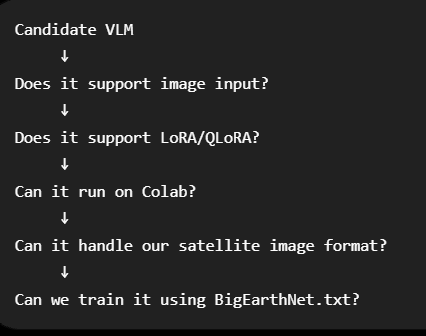

## **Step 4 — Prove one tiny training run works**

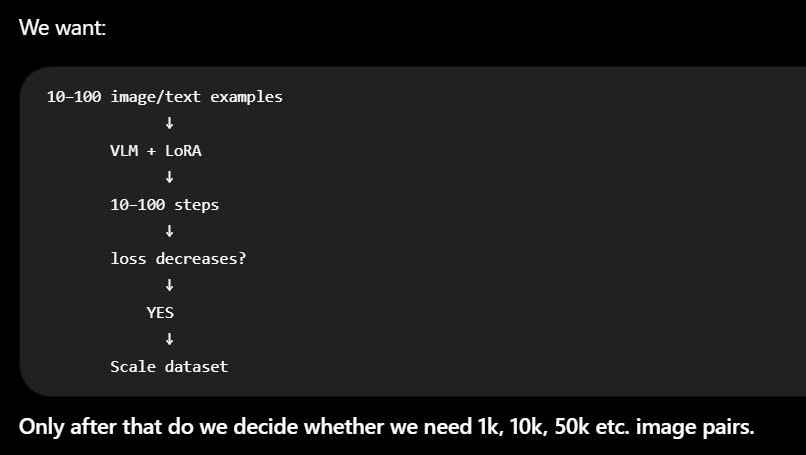

# **DATASET2: BigEarthNet-v2.0 S1/S2 imagery**

https://huggingface.co/datasets/hackelle/BigEarthNetV2-Lithuania-Summer-LMDB?utm_source=chatgpt.com

## **Cell 1 — Install the required libraries**

In [10]:
!pip -q install datasets huggingface_hub lmdb safetensors pyarrow pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.8/346.8 kB 3.8 MB/s eta 0:00:00


## **Cell 2 — Download the small dataset**

In [4]:
from huggingface_hub import snapshot_download

repo_id = "hackelle/BigEarthNetV2-Lithuania-Summer-LMDB"

local_dir = snapshot_download(
    repo_id=repo_id,
    repo_type="dataset"
)

print("Downloaded to:")
print(local_dir)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Downloaded to:
/root/.cache/huggingface/hub/datasets--hackelle--BigEarthNetV2-Lithuania-Summer-LMDB/snapshots/7a83ae701109ec232d40665b9677fc46310a1a8b


In [5]:
import os

for root, dirs, files in os.walk(local_dir):
    level = root.replace(local_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        size_mb = os.path.getsize(os.path.join(root, file)) / (1024**2)
        print(f"{indent}  {file} — {size_mb:.2f} MB")

7a83ae701109ec232d40665b9677fc46310a1a8b/
  README.md — 0.01 MB
  .gitattributes — 0.00 MB
  metadata_lithuania_summer.parquet — 0.24 MB
  BENv2_lithuania_summer.lmdb/
    lock.mdb — 0.01 MB
    data.mdb — 2366.88 MB


## **Cell — 3 Load Dataset**

In [6]:
import os

lmdb_files = []
parquet_files = []

for root, dirs, files in os.walk(local_dir):
    for file in files:
        full_path = os.path.join(root, file)

        if file.endswith(".lmdb"):
            lmdb_files.append(full_path)

        elif file.endswith(".parquet"):
            parquet_files.append(full_path)

print("LMDB files:")
for x in lmdb_files:
    print(x)

print("\nParquet files:")
for x in parquet_files:
    print(x)

LMDB files:

Parquet files:
/root/.cache/huggingface/hub/datasets--hackelle--BigEarthNetV2-Lithuania-Summer-LMDB/snapshots/7a83ae701109ec232d40665b9677fc46310a1a8b/metadata_lithuania_summer.parquet


## **Cell 4 — Explore Dataset**

In [7]:
import os

# Find the LMDB directory
lmdb_path = None
parquet_path = None

for root, dirs, files in os.walk(local_dir):

    # LMDB is a DIRECTORY, not a .lmdb file
    if os.path.basename(root) == "BENv2_lithuania_summer.lmdb":
        lmdb_path = root

    for file in files:
        if file.endswith(".parquet"):
            parquet_path = os.path.join(root, file)

print("LMDB directory:")
print(lmdb_path)

print("\nMetadata:")
print(parquet_path)

LMDB directory:
/root/.cache/huggingface/hub/datasets--hackelle--BigEarthNetV2-Lithuania-Summer-LMDB/snapshots/7a83ae701109ec232d40665b9677fc46310a1a8b/BENv2_lithuania_summer.lmdb

Metadata:
/root/.cache/huggingface/hub/datasets--hackelle--BigEarthNetV2-Lithuania-Summer-LMDB/snapshots/7a83ae701109ec232d40665b9677fc46310a1a8b/metadata_lithuania_summer.parquet


In [8]:
import pandas as pd

subset_df = pd.read_parquet(parquet_path)

print("Shape:", subset_df.shape)
print("\nColumns:")
print(subset_df.columns.tolist())

display(subset_df.head())

Shape: (8775, 8)

Columns:
['patch_id', 'labels', 'split', 'country', 's1_name', 's2v1_name', 'contains_seasonal_snow', 'contains_cloud_or_shadow']


,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
39329,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_54,S2A_MSIL2A_20170720T100031_61_54,False,False
39330,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_55,S2A_MSIL2A_20170720T100031_61_55,False,False
39331,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_56,S2A_MSIL2A_20170720T100031_61_56,False,False
39332,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_62_52,S2A_MSIL2A_20170720T100031_62_52,False,False
39333,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_62_53,S2A_MSIL2A_20170720T100031_62_53,False,False


## **Cell 5 — open the LMDB**

In [11]:
import lmdb

env = lmdb.open(
    lmdb_path,
    readonly=True,
    lock=False,
    readahead=False,
    max_readers=126
)

print("LMDB opened successfully!")

LMDB opened successfully!


## **Cell 6 — Load one actual S2 patch**

In [12]:
from safetensors.numpy import load as safetensor_load

# Pick first patch
patch_id = subset_df["patch_id"].iloc[0]

print("Patch ID:")
print(patch_id)

# Retrieve from LMDB
with env.begin(write=False) as txn:
    raw_data = txn.get(patch_id.encode())

print("\nData found:", raw_data is not None)

if raw_data is not None:
    print("Size:", len(raw_data) / (1024**2), "MB")

Patch ID:
S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_61_54

Data found: True
Size: 0.15338134765625 MB


## **Cell 7 — Decode it**

In [13]:
s2 = safetensor_load(raw_data)

print("Available Sentinel-2 bands:")
print(list(s2.keys()))

Available Sentinel-2 bands:
['B11', 'B01', 'B04', 'B06', 'B8A', 'B03', 'B05', 'B09', 'B08', 'B12', 'B07', 'B02']


## **Inspect Dimensions**

In [14]:
for band, array in s2.items():
    print(
        f"{band:>3} | "
        f"shape={array.shape} | "
        f"dtype={array.dtype} | "
        f"min={array.min():.3f} | "
        f"max={array.max():.3f}"
    )

B11 | shape=(60, 60) | dtype=uint16 | min=27.000 | max=67.000
B01 | shape=(20, 20) | dtype=uint16 | min=255.000 | max=281.000
B04 | shape=(120, 120) | dtype=uint16 | min=94.000 | max=182.000
B06 | shape=(60, 60) | dtype=uint16 | min=57.000 | max=113.000
B8A | shape=(60, 60) | dtype=uint16 | min=36.000 | max=98.000
B03 | shape=(120, 120) | dtype=uint16 | min=210.000 | max=311.000
B05 | shape=(60, 60) | dtype=uint16 | min=87.000 | max=151.000
B09 | shape=(20, 20) | dtype=uint16 | min=40.000 | max=82.000
B08 | shape=(120, 120) | dtype=uint16 | min=45.000 | max=125.000
B12 | shape=(60, 60) | dtype=uint16 | min=14.000 | max=63.000
B07 | shape=(60, 60) | dtype=uint16 | min=49.000 | max=109.000
B02 | shape=(120, 120) | dtype=uint16 | min=171.000 | max=296.000


## **RGB visualization**

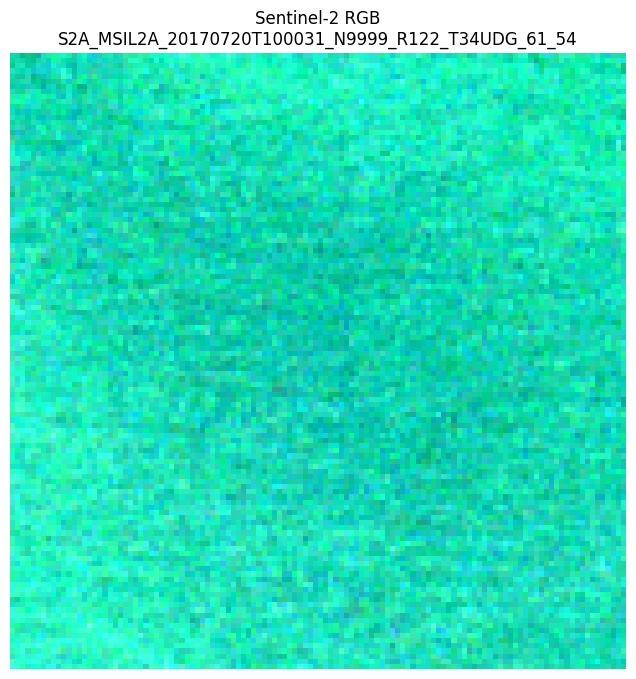

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Sentinel-2 RGB bands
red   = s2["B04"]
green = s2["B03"]
blue  = s2["B02"]

# Stack into RGB image
rgb = np.stack([red, green, blue], axis=-1)

# Normalize for visualization
rgb_min = np.percentile(rgb, 2)
rgb_max = np.percentile(rgb, 98)

rgb_display = np.clip(
    (rgb - rgb_min) / (rgb_max - rgb_min),
    0,
    1
)

# Display
plt.figure(figsize=(8, 8))
plt.imshow(rgb_display)
plt.title(f"Sentinel-2 RGB\n{patch_id}")
plt.axis("off")
plt.show()

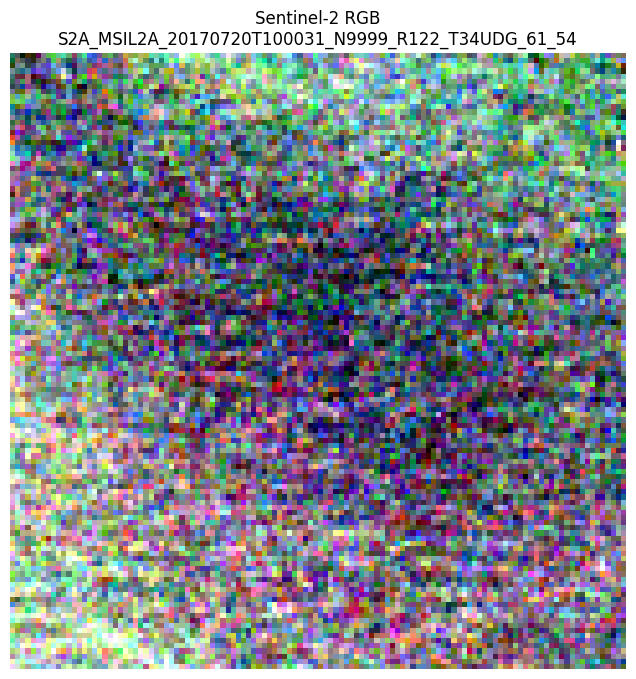

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_band(band, low=2, high=98):
    p_low = np.percentile(band, low)
    p_high = np.percentile(band, high)

    band = np.clip(band, p_low, p_high)

    return (band - p_low) / (p_high - p_low + 1e-8)


red   = normalize_band(s2["B04"])
green = normalize_band(s2["B03"])
blue  = normalize_band(s2["B02"])

rgb_display = np.stack(
    [red, green, blue],
    axis=-1
)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_display)
plt.title(f"Sentinel-2 RGB\n{patch_id}")
plt.axis("off")
plt.show()

### **Where is the original image stored?**


It is not stored as:

```
something.jpg
something.png
something.tif
```

Instead, the original downloaded data is currently here:

```
/root/.cache/huggingface/hub/
└── datasets--hackelle--BigEarthNetV2-Lithuania-Summer-LMDB/
    └── snapshots/
        └── 7a83ae701109ec232d40665b9677fc46310a1a8b/
            └── BENv2_lithuania_summer.lmdb/
                ├── data.mdb    ← ~2.37 GB
                └── lock.mdb
```

data.mdb is the LMDB database.

## **Normalize each RGB band independently:**

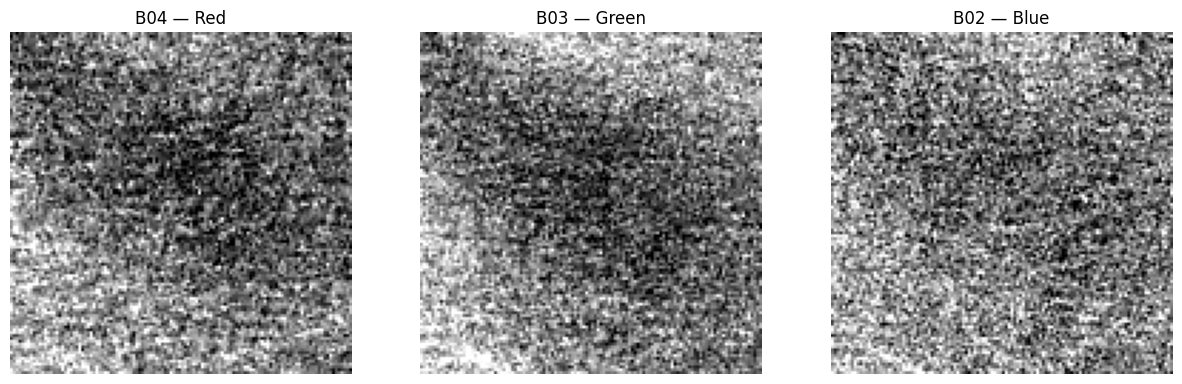

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(normalize_band(s2["B04"]), cmap="gray")
axes[0].set_title("B04 — Red")

axes[1].imshow(normalize_band(s2["B03"]), cmap="gray")
axes[1].set_title("B03 — Green")

axes[2].imshow(normalize_band(s2["B02"]), cmap="gray")
axes[2].set_title("B02 — Blue")

for ax in axes:
    ax.axis("off")

plt.show()

# **COMBINE BOTH DATASETS**

| Dataset                                  | What it contains                                                   | Actual pixels? | Questions/answers? |
| ---------------------------------------- | ------------------------------------------------------------------ | -------------: | -----------------: |
| **BigEarthNet.txt**                      | `patch_id`, `input`/question, `output`/answer, task/category, etc. |           ❌ No |              ✅ Yes |
| **BigEarthNet v2 Lithuania-Summer LMDB** | Actual Sentinel-1 + Sentinel-2 patches                             |          ✅ Yes |               ❌ No |


### PRoposed Pipleine

```
                 BigEarthNet.txt
                       │
              patch_id + question
              + answer + task
                       │
                       │ JOIN
                       ▼
       BigEarthNet v2 image subset
                       │
                patch_id + image
                       │
                       ▼
             ┌─────────────────┐
             │ FINAL DATASET   │
             │                 │
             │ image           │
             │ question        │
             │ answer          │
             │ task/category   │
             │ patch metadata  │
             └─────────────────┘
                       │
                       ▼
                 Fine-tune VLM
```

Dataset understanding: We currently have two complementary datasets.

1. BigEarthNet.txt — this is mainly the text/annotation side. It has ~9.55M rows containing things like patch_id, questions/instructions (input), answers (output), task/category, etc. It does not contain the actual satellite pixels.

2. BigEarthNet v2 Lithuania-Summer LMDB — this contains the actual Sentinel-1 and Sentinel-2 satellite image data. We downloaded the ~2.5GB subset containing 8,775 unique patches. The images are stored as numerical pixel/sensor tensors (SafeTensors inside LMDB), not normal JPG/PNG images.

The important thing is that both datasets have identifiers such as patch_id, so we can join them. One image/patch can have multiple questions and answers, meaning 8,775 unique images can potentially produce many more training examples.

So our intended pipeline is:

BigEarthNet.txt (Q/A + patch IDs) + BigEarthNet v2 (actual S1/S2 imagery) → joined image + question + answer dataset → VLM fine-tuning.

Also, "patch" doesn't mean an object highlighted inside the satellite image. BigEarthNet has already divided the satellite imagery into predefined geographic patches. We don't need OpenCV to detect those patches for the dataset. If later we receive a huge satellite scene from a user, we may need an image-tiling/preprocessing step to divide it into patches.

The VLM's job is then to understand the satellite patch and answer the question. We are not primarily training it to recognize patch IDs. We are training it for remote-sensing understanding/VQA/captioning/etc.

Next step: join the 8,775 image patches with BigEarthNet.txt and calculate exactly how many Q/A training samples we get. Then we can decide whether this subset is sufficient for our initial fine-tuning experiment.

## **Cell 1 — Check the BigEarthNet.txt columns**

In [20]:
print("BigEarthNet.txt shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

BigEarthNet.txt shape: (9553962, 13)

Columns:
['ID', 's1_name', 'patch_id', 'input', 'output', 'type', 'category', 'split', 'latitude', 'longitude', 'country', 'season', 'climate_zone']


## **Step 2 — Check how many UNIQUE patches are in BigEarthNet.txt**

In [22]:
print("Total annotation rows:", len(df))
print("Unique patch IDs:", df["patch_id"].nunique())
print("Unique S1 images:", df["s1_name"].nunique())

Total annotation rows: 9553962
Unique patch IDs: 464044
Unique S1 images: 464044


## **Step 3 — Check your 8,775-image dataset**

In [23]:
print("Total image rows:", len(subset_df))
print("Unique patch IDs:", subset_df["patch_id"].nunique())
print("Unique S1 images:", subset_df["s1_name"].nunique())

Total image rows: 8775
Unique patch IDs: 8775
Unique S1 images: 8775


## **Step 4 — Find the patch IDs that exist in BOTH datasets**

In [24]:
text_patch_ids = set(df["patch_id"].dropna())
image_patch_ids = set(subset_df["patch_id"].dropna())

common_patch_ids = text_patch_ids.intersection(image_patch_ids)

print("Unique patches in BigEarthNet.txt :", len(text_patch_ids))
print("Unique patches in image dataset   :", len(image_patch_ids))
print("Patches present in BOTH            :", len(common_patch_ids))

Unique patches in BigEarthNet.txt : 464044
Unique patches in image dataset   : 8775
Patches present in BOTH            : 8363


## **Step 5 — Actually combine them**

In [25]:
matched = df.merge(
    subset_df,
    on="patch_id",
    how="inner",
    suffixes=("_text", "_image")
)

print("Matched annotation rows:", len(matched))
print("Unique matched patches:", matched["patch_id"].nunique())

Matched annotation rows: 185443
Unique matched patches: 8363


## **Step 6 — See what the combined dataset actually looks like**

In [26]:
print("Columns in combined dataset:")
print(matched.columns.tolist())

Columns in combined dataset:
['ID', 's1_name_text', 'patch_id', 'input', 'output', 'type', 'category', 'split_text', 'latitude', 'longitude', 'country_text', 'season', 'climate_zone', 'labels', 'split_image', 'country_image', 's1_name_image', 's2v1_name', 'contains_seasonal_snow', 'contains_cloud_or_shadow']


In [29]:
display(
    matched[
        ["patch_id", "input", "output", "type", "category"]
    ].head(10)
)

,patch_id,input,output,type,category
0,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,Would you say that any inland water lies next ...,no,binary,adjacency
1,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,Is there some part of the image not covered by...,no,binary,area
2,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,Is the region of marine waters greater than 90%?,yes,binary,area
3,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,Is there more than a single connected instance...,no,binary,count
4,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,Would you say that there are less than four co...,yes,binary,count
5,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,Would you classify part of this image as marin...,yes,binary,presence
6,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,Would you say the satellite image shows inland...,no,binary,presence
7,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,Explain the landscape features visible in this...,"This satellite image, captured during the summ...",captioning,None
8,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,Pick the area range for marine waters: a) 4320...,d,mcq,area
9,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,Which of the following climate zones does this...,c,mcq,climate zone


## **Step 7 — Count questions/annotations per image**

In [30]:
questions_per_patch = (
    matched
    .groupby("patch_id")
    .size()
    .sort_values(ascending=False)
)

print(questions_per_patch.head(20))

patch_id
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_64_53    51
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_29_61    41
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_36_16    37
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_09_61    37
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_55_44    36
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_41_79    36
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_66_44    35
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_76_54    35
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_42_05    35
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_54_56    35
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_52_28    35
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_25_59    35
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_59_51    35
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_59_07    35
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_03_86    35
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_58_31    35
S2B_MSIL2A_20170808T094029_N9999_R036_T35ULA_37_43    35
S2B_MSIL2A_20170808T09

## **Some Stats**

In [31]:
print("Average annotations per matched patch:",
      questions_per_patch.mean())

print("Median annotations per matched patch:",
      questions_per_patch.median())

print("Maximum annotations for one patch:",
      questions_per_patch.max())

Average annotations per matched patch: 22.174219777591773
Median annotations per matched patch: 23.0
Maximum annotations for one patch: 51


## **Step 8 — See the distribution of tasks**

In [32]:
print("Training examples by task type:")
print(matched["type"].value_counts())

Training examples by task type:
type
binary          65454
mcq             60130
bounding box    51497
captioning       8362
Name: count, dtype: int64


In [33]:
print("\nTraining examples by category:")
print(matched["category"].value_counts())


Training examples by category:
category
point           26282
reference       25215
count           25075
presence        25071
area            25070
adjacency       22239
None             8362
country          8360
season           8359
climate zone     8355
relative pos     3055
Name: count, dtype: int64


## **Step 9 — Pick ONE actual image + its question**

In [34]:
sample = matched.iloc[0]

print("PATCH ID:")
print(sample["patch_id"])

print("\nQUESTION / INPUT:")
print(sample["input"])

print("\nANSWER / OUTPUT:")
print(sample["output"])

print("\nTASK:")
print(sample["type"])

print("\nCATEGORY:")
print(sample["category"])

PATCH ID:
S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_61_55

QUESTION / INPUT:
Would you say that any inland water lies next to marine waters in the image?

ANSWER / OUTPUT:
no

TASK:
binary

CATEGORY:
adjacency


## **Step 10 — Retrieve THAT exact image from LMDB**

In [35]:
patch_id = sample["patch_id"]

with env.begin(write=False) as txn:
    raw_data = txn.get(patch_id.encode())

print("Patch:", patch_id)
print("Image found in LMDB:", raw_data is not None)
print("Encoded size:", len(raw_data) / (1024**2), "MB")

Patch: S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_61_55
Image found in LMDB: True
Encoded size: 0.15338134765625 MB


## **Step 11 — Decode the actual satellite image**

In [36]:
from safetensors.numpy import load as safetensor_load

s2_sample = safetensor_load(raw_data)

print("Sentinel-2 bands:")
print(list(s2_sample.keys()))

Sentinel-2 bands:
['B12', 'B04', 'B02', 'B08', 'B03', 'B01', 'B8A', 'B06', 'B05', 'B07', 'B09', 'B11']


# **Step 12 — Display the actual patch**

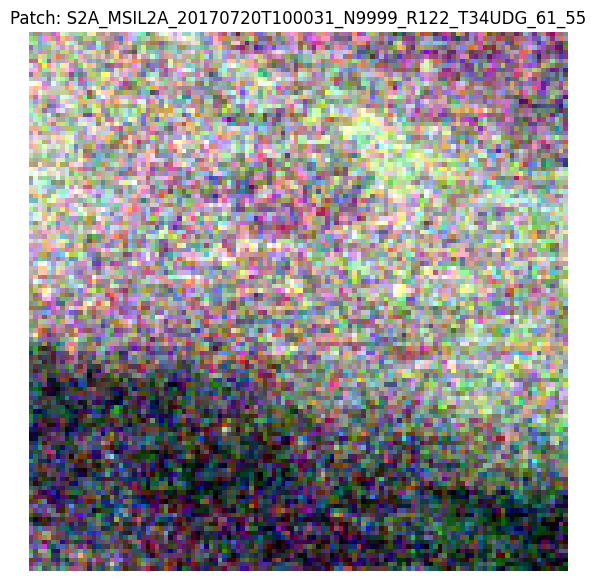

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_band(band, low=2, high=98):
    band = band.astype(np.float32)
    p_low, p_high = np.percentile(band, [low, high])
    band = np.clip(band, p_low, p_high)
    return (band - p_low) / (p_high - p_low + 1e-8)

red = normalize_band(s2_sample["B04"])
green = normalize_band(s2_sample["B03"])
blue = normalize_band(s2_sample["B02"])

rgb = np.stack([red, green, blue], axis=-1)

plt.figure(figsize=(7, 7))
plt.imshow(rgb)
plt.title(f"Patch: {patch_id}")
plt.axis("off")
plt.show()

## **Step 13 — Print the Q/A beside the image**

In [38]:
print("=" * 70)
print("TRAINING EXAMPLE")
print("=" * 70)

print("\nPatch ID:")
print(patch_id)

print("\nQuestion:")
print(sample["input"])

print("\nAnswer:")
print(sample["output"])

TRAINING EXAMPLE

Patch ID:
S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_61_55

Question:
Would you say that any inland water lies next to marine waters in the image?

Answer:
no


# **FINAL DATASET**

In [39]:
# Size of the current combined DataFrame in RAM
memory_mb = matched.memory_usage(deep=True).sum() / (1024**2)

prinat(f"Current matched DataFrame memory: {memory_mb:.2f} MB")
print(f"Rows: {len(matched):,}")
print(f"Columns: {len(matched.columns)}")

Current matched DataFrame memory: 218.65 MB
Rows: 185,443
Columns: 20


In [40]:
training_df = matched[
    [
        "patch_id",
        "input",
        "output",
        "type",
        "category",
        "split_text",
        "latitude",
        "longitude",
        "country_text",
        "season",
        "climate_zone"
    ]
].copy()

print("Training metadata shape:", training_df.shape)

training_memory_mb = (
    training_df.memory_usage(deep=True).sum() / (1024**2)
)

print(f"Training metadata RAM: {training_memory_mb:.2f} MB")

Training metadata shape: (185443, 11)
Training metadata RAM: 128.56 MB


## **Save & Download**

In [43]:
training_df.to_csv(
    "/content/training.csv",
    index=False
)

print("Saved!")

Saved!


In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import os
import shutil

dataset_dir = "/content/drive/MyDrive/SatQueryAI/dataset"
os.makedirs(dataset_dir, exist_ok=True)

shutil.copy(
    "/content/training.csv",
    dataset_dir
)

print("Training CSV saved to:")
print(dataset_dir)

Training CSV saved to:
/content/drive/MyDrive/SatQueryAI/dataset


**Copy the actual satellite images**

In [46]:
# images path

lmdb_path

'/root/.cache/huggingface/hub/datasets--hackelle--BigEarthNetV2-Lithuania-Summer-LMDB/snapshots/7a83ae701109ec232d40665b9677fc46310a1a8b/BENv2_lithuania_summer.lmdb'

In [47]:
import shutil
import os

target_lmdb = os.path.join(
    dataset_dir,
    "BENv2_lithuania_summer.lmdb"
)

shutil.copytree(
    lmdb_path,
    target_lmdb,
    dirs_exist_ok=True
)

print("LMDB copied to:")
print(target_lmdb)

LMDB copied to:
/content/drive/MyDrive/SatQueryAI/dataset/BENv2_lithuania_summer.lmdb


## **Setup Call**

In [48]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_DIR = "/content/drive/MyDrive/SatQueryAI/dataset"

CSV_PATH = f"{DATASET_DIR}/training.csv"
LMDB_PATH = f"{DATASET_DIR}/BENv2_lithuania_summer.lmdb"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import pandas as pd
import lmdb

training_df = pd.read_csv(CSV_PATH)

env = lmdb.open(
    LMDB_PATH,
    readonly=True,
    lock=False,
    readahead=False,
    max_readers=126
)

print(training_df.shape)

(185443, 11)
